# Word Embeddings

In [2]:
%pip install gensim

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\sugan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import csv
import spacy

In [4]:
class Corpus(object):

    def __init__(self, filename):
        self.filename = filename
        self.nlp = spacy.blank("en")

    def __iter__(self):
        with open(self.filename, 'r', encoding='utf-8') as i:
            reader = csv.reader(i, delimiter=",")
            for _, abstract in reader:
                tokens = [t.text.lower() for t in self.nlp(abstract)]
                yield tokens

documents = Corpus("arxiv.csv")

In [5]:
documents = list(documents)

In [6]:
import gensim

model = gensim.models.Word2Vec(documents, min_count=100, window=5, vector_size=100)

model.wv["nlp"]

array([ 0.344269  , -0.17875656,  1.92188   , -0.1159924 ,  1.7259363 ,
       -0.4353388 ,  0.6769907 ,  1.0960584 , -0.8730976 ,  1.1664027 ,
       -1.6654863 , -2.687677  ,  1.9833411 ,  0.83428174, -0.01060425,
        0.06394946, -0.5447579 ,  1.4726025 ,  0.17813312,  2.1882808 ,
        0.68264294, -0.7456435 ,  1.4297488 ,  0.9252904 , -2.314449  ,
       -2.5290394 ,  1.5975676 ,  0.44771984,  2.3866127 , -0.01521693,
        0.3000689 ,  0.5723033 ,  0.57037556,  1.3888388 , -1.3179512 ,
       -2.8789153 ,  0.5346767 , -4.073777  , -1.0912923 ,  2.066521  ,
       -1.1598333 , -1.3630762 ,  2.2240746 ,  0.17535767, -1.2378438 ,
        0.05372179,  2.005479  ,  1.0811331 , -1.8543748 , -2.9547431 ,
        1.5832037 ,  2.1498954 ,  0.07158338, -1.0451708 ,  0.96833533,
        0.05775855, -0.04803406,  1.3089659 ,  3.4801214 ,  0.25590095,
        0.72506195,  2.2352164 , -1.5554422 ,  0.49334   ,  0.17505755,
       -1.2165638 , -0.3665116 , -2.1072176 ,  1.1782027 , -1.30

In [7]:
print(model.wv.similarity("nlp", "language"))

0.36886942


In [8]:
print(model.wv.most_similar("nlp"))

[('nlu', 0.6118658781051636), ('downstream', 0.6061365604400635), ('ai', 0.5769649744033813), ('ir', 0.5468010902404785), ('nlg', 0.5444322824478149), ('ner', 0.5393679738044739), ('mrc', 0.5348859429359436), ('ml', 0.5264403223991394), ('modern', 0.518541693687439), ('nli', 0.5083174109458923)]


In [16]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE



target_word = "bert"
selected_words = [w[0] for w in model.wv.most_similar(positive=[target_word], topn=200)] + [target_word]
embeddings = [model.wv[w] for w in selected_words] + model.wv[target_word]

mapped_embeddings = TSNE(n_components=2,metric='cosine', init='pca').fit_transform(embeddings)

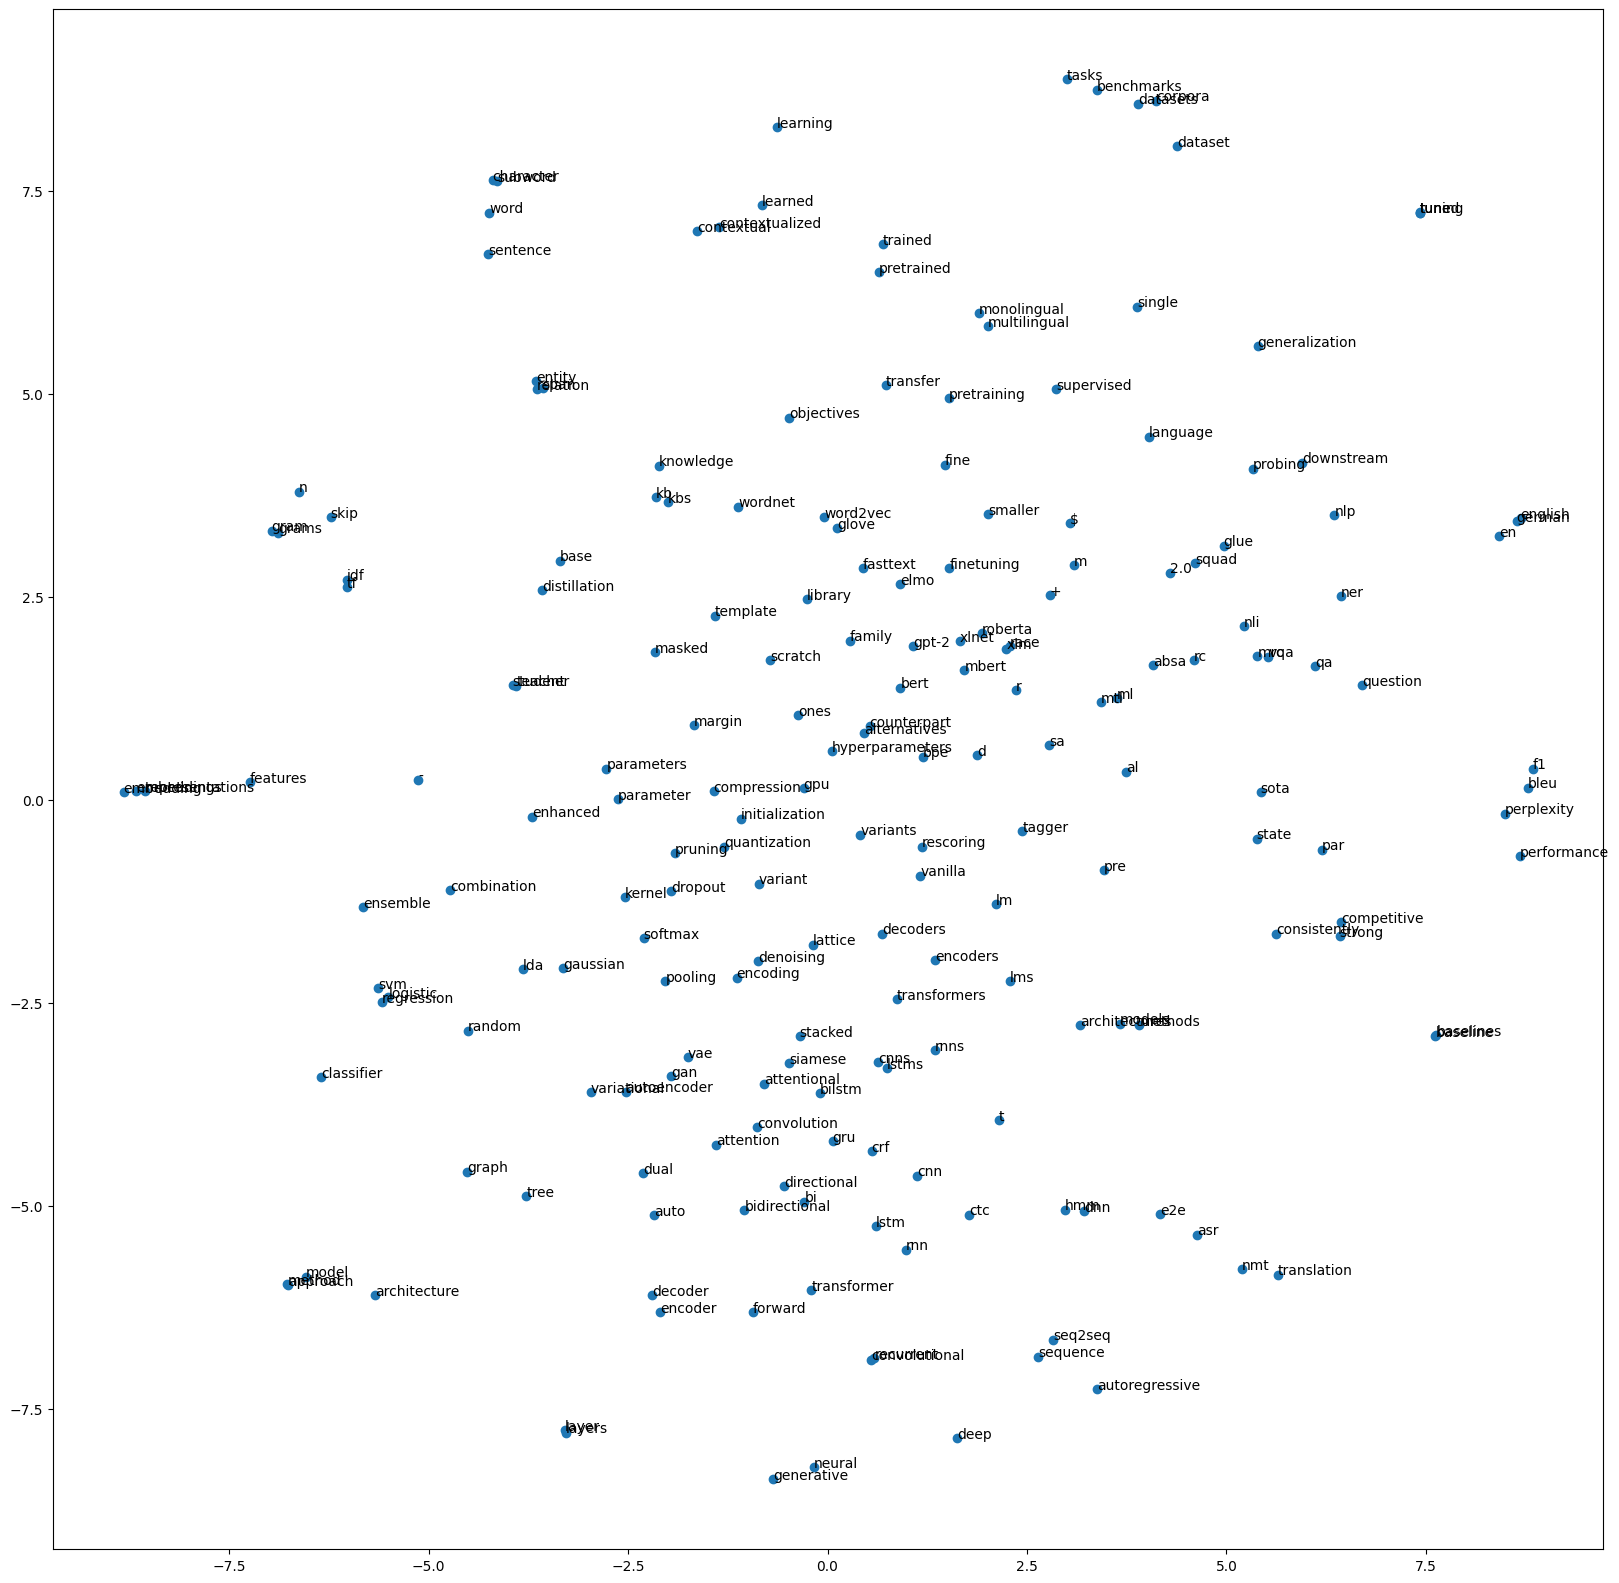

In [22]:
plt.figure(figsize=(20, 20))
x = mapped_embeddings[:, 0]
y = mapped_embeddings[:, 1]
plt.scatter(x, y)

for i, word in enumerate(selected_words):
    plt.annotate(word, (x[i], y[i]))